In [1]:
import os, re, faiss
import asyncio
import numpy as np
from openai import OpenAI
from sentence_transformers import SentenceTransformer

from src.GraphRAG import GraphRAG
from src.index.Chunker import Chunker
from src.index.GraphBuilder import GraphBuilder
from src.index.GraphAnalyzer import GraphAnalyzer
from src.retrieve.GlobalSearcher import GlobalSearcher
from src.retrieve.LocalSearcher import LocalSearcher
from src.LLM import vLLMInterface
from dotenv import load_dotenv
load_dotenv()

True

In [2]:

embed_model = SentenceTransformer("BAAI/bge-m3", device="cuda:2")

chunker = Chunker(
    chunk_size=512, overlap=50, encoding_model="cl100k_base", 
    embed_model=embed_model
)
vllm = vLLMInterface(
    base_url="http://localhost:8000/v1", model="Qwen/Qwen3.5-9B", 
    enable_thinking=False, temperature=0
)
graph_builder = GraphBuilder(LLM=vllm, embed_model=embed_model)
graph_analyzer = GraphAnalyzer(LLM=vllm, embed_model=embed_model, max_community_size=50)

	LLM: Qwen/Qwen3.5-9B at http://localhost:8000/v1


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

def visualize_graph_by_community(graph):
    node_weights = {n[0]: n[1]['weight'] for n in graph.nodes(data=True)}
    node_weights_mean = np.mean(list(node_weights.values()))
    node_weights_std = np.std(list(node_weights.values()))
    relative_node_weights = {k: (v-node_weights_mean)/node_weights_std for k, v in node_weights.items()}
    
    node_community_ids = {n[0]: n[1]['community_id'] for n in graph.nodes(data=True)}
    unique_comms = sorted(set(node_community_ids.values()))
    cmap = cm.get_cmap("tab20", len(unique_comms))
    comm_to_color = {c: cmap(i) for i, c in enumerate(unique_comms)}
    node_colors = {k: comm_to_color[v] for k, v in node_community_ids.items()}

    edge_weights = {}
    for u, v, relation, edge_data in graph.edges(keys=True, data=True):
        if (u, v) in edge_weights:
            edge_weights[(u, v)] += edge_data['weight']
        elif (v, u) in edge_weights:
            edge_weights[(v, u)] += edge_data['weight']
        else:
            edge_weights[(u, v)] = edge_data['weight']
    edge_weights_mean = np.mean(list(edge_weights.values()))
    edge_weights_std = np.std(list(edge_weights.values()))
    relative_edge_weights = {k: (v-edge_weights_mean)/edge_weights_std for k, v in edge_weights.items()}

    pos = nx.spring_layout(graph, k=4, seed=42)

    plt.figure(figsize=(12, 10))
    nx.draw_networkx_nodes(
        graph, pos, node_color=list(node_colors.values()),
        node_size=[1e3*(v+2) for v in relative_node_weights.values()],
        alpha=0.9
    )
    nx.draw_networkx_edges(
        graph, pos,
        edgelist=list(edge_weights.keys()),
        width=3, #[(v+2) for v in relative_edge_weights.values()],
        edge_color="gray", alpha=0.5, connectionstyle='arc3,rad=0.1',
        arrows=True, arrowstyle='->', arrowsize=15,
        
    )

    for n in graph.nodes:
        x, y = pos[n]
        w = relative_node_weights[n]
        plt.text(x, y, s=n.replace(' ', '\n'), fontsize=4*(w+3), ha='center', va='center', color='black')
    
    for comm, color in comm_to_color.items():
        plt.scatter([], [], c=[color], label=f"Community {comm}")

    plt.legend(markerscale=2, fontsize=8)

    plt.title("LHC Knowledge Graph Visualization")
    plt.axis("off")
    plt.tight_layout()
    plt.show()
    plt.savefig('./data/meta_KG.pdf')


Graph loaded: 5693 nodes and 11235 edges
Node embeddings loaded: dimension=1024, number of vectors=5693


/tmp/ipykernel_3086736/1024950410.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", len(unique_comms))


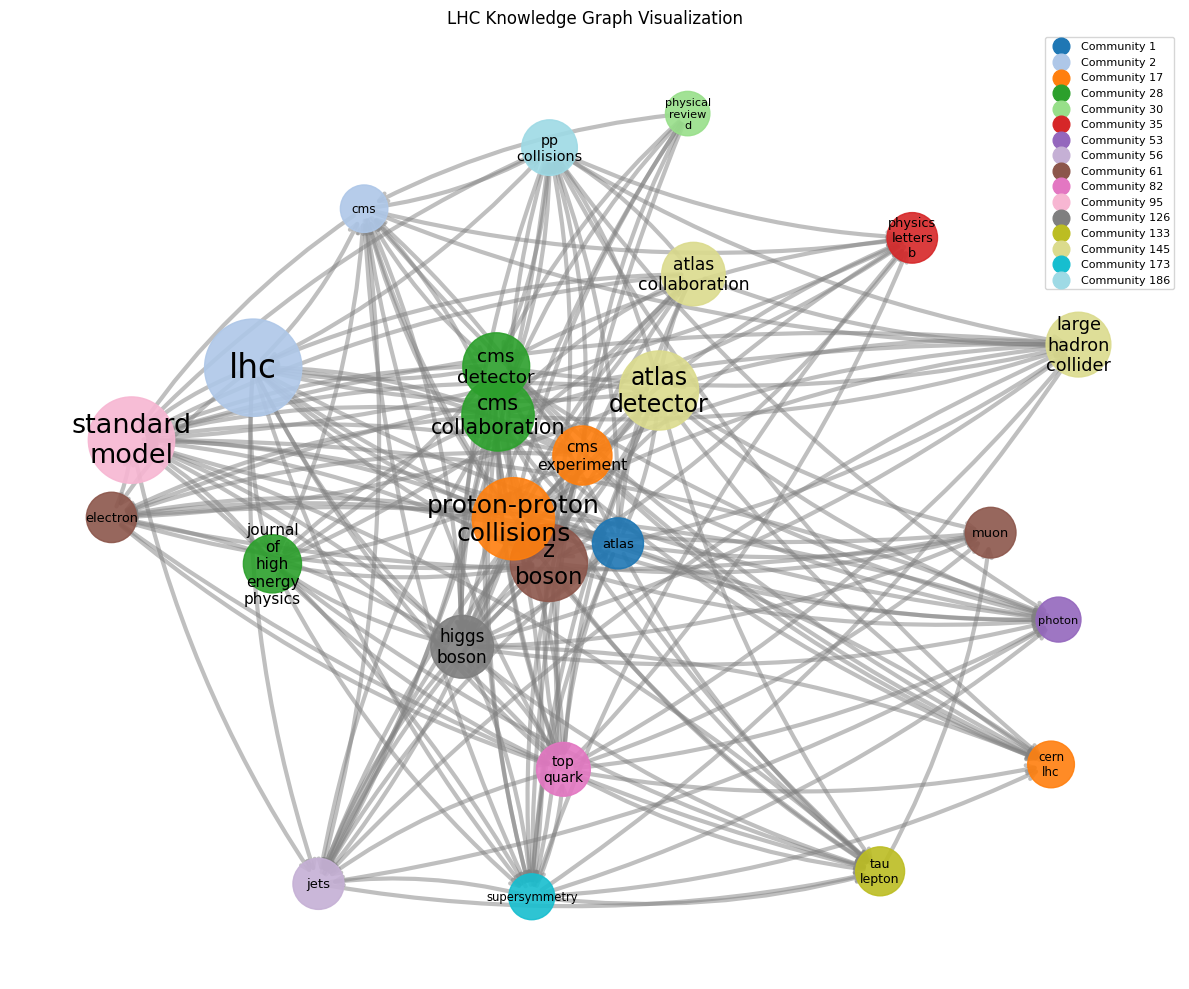

<Figure size 640x480 with 0 Axes>

In [64]:
graph, node_embeddings = graph_builder.load(
    graph_path='checkpoints/graph.json',
    index_path='checkpoints/nodes.index'
)

top_nodes = sorted(
    graph.nodes(data=True), 
    key=lambda x: x[1].get('weight', 0), 
    reverse=True
)[:25]
top_node_ids = [n[0] for n in top_nodes]
subgraph = graph.subgraph(top_node_ids)
visualize_graph_by_community(subgraph)

In [ ]:
log_node_weights = np.log(node_weights)
log_node_weights

In [ ]:
chunks = chunker.load_chunks('checkpoints/chunks.json')
graph, node_embeddings = graph_builder.load(
    graph_path='checkpoints/graph.json',
    index_path='checkpoints/nodes.index'
)

for node, node_data in graph.nodes(data=True):
    if 'type' not in node_data or 'weight' not in node_data:
        print(node)
for source, target, edge_data in graph.edges(data=True):
    if 'weight' not in edge_data:
        print(source, target, edge_data)

In [ ]:
community_embeddings, community_summaries = graph_analyzer.load(
    index_path='checkpoints/communities.index',
    meta_path='checkpoints/communities.json',
)

In [ ]:
query = "The Xbb tagger calibration uses g→bb jets as proxies for H/Z→bb jets. However, the color flow and substructure of gluon splitting differ from boson decay. What systematic uncertainty is assigned to account for this difference?"
global_searcher = GlobalSearcher(LLM=vllm, embed_model=embed_model, community_reports=community_summaries, community_embeddings=community_embeddings)
global_answer = global_searcher.search(query)
with open('answers/global_answer.md', 'w') as f:
    f.write(query+"\n\n"+global_answer)

In [ ]:
local_searcher = LocalSearcher(graph=graph, node_embeddings=node_embeddings, chunks=chunks, community_summaries=community_summaries, embed_model=embed_model, LLM=vllm)
local_answer = local_searcher.search(query)
with open('answers/local_answer.md', 'w') as f:
    f.write(query+"\n\n"+local_answer)

In [ ]:
graph, hierarchy, global_summary = community_analyzer.analyze(graph=graph)

In [ ]:
import requests

BASE = "https://inspirehep.net/api/literature"

params = {
    "q": 'collaboration:"ATLAS" AND collection:Published', #"Higgs",
    #"sort": "mostrecent",
    "size": 25,
    "fields": "titles,arxiv_eprints,dois,files,control_number"
}

r = requests.get(BASE, params=params)
data = r.json()

hit = data["hits"]["hits"][0]
meta = hit["metadata"]

title = meta["titles"][0]["title"]
recid = meta["control_number"]   # 关键ID
arxiv_id = meta.get("arxiv_eprints", [{}])[0].get("value")
print(arxiv_id is None)
print(meta)
print(recid)



In [ ]:
import requests
import os
import time

BASE = "https://inspirehep.net/api/literature"

SAVE_DIR = "./papers"
os.makedirs(SAVE_DIR, exist_ok=True)


def fetch_papers(query, size=25, max_pages=5):
    papers = []
    for page in range(1, max_pages + 1):
        params = {
            "q": query,
            "size": size,
            "page": page,
            "fields": "titles,arxiv_eprints,dois,control_number"
        }

        r = requests.get(BASE, params=params)
        data = r.json()

        hits = data["hits"]["hits"]
        if not hits:
            break

        papers.extend(hits)
        print(f"Fetched page {page}, total papers: {len(papers)}")

        time.sleep(0.5)

    return papers


def download_pdf(output_dir='data', doi=None, arxiv=None):
    if doi:
        url = f"https://doi.org/{doi}"
        try:
            r = requests.get(url, timeout=20, allow_redirects=True)
            if r.status_code == 200 and "pdf" in r.headers.get("content-type", "").lower():
                with open(os.path.join(output_dir, f"{doi}.pdf"), "wb") as f:
                    f.write(r.content)
                return
            else:
                print(f"\tDOI failed (status/content-type): {url}")
        except Exception as e:
            print(f"\tDOI error: {e}")
    if arxiv:
        url = f"https://arxiv.org/pdf/{arxiv}.pdf"
        try:
            r = requests.get(url, timeout=20)
            if r.status_code == 200:
                with open(os.path.join(output_dir, f"{arxiv}.pdf"), "wb") as f:
                    f.write(r.content)
                return
            else:
                print(f"\tarXiv failed (status): {url}")
        except Exception as e:
            print(f"\tarXiv error: {e}")

    print("All download attempts failed.")


# ======================
# 主流程
# ======================

queries = {
    "ATLAS": 'collaboration:"ATLAS" AND collection:Published',
    "CMS": 'collaboration:"CMS" AND collection:Published'
}

for tag, query in queries.items():

    papers = fetch_papers(query)

    for i, hit in enumerate(papers):
        meta = hit["metadata"]
        title = meta.get("titles", [{}])[0].get("title", "")

        pdf_url = get_pdf_url(meta)
        if not pdf_url:
            continue

        safe_title = "".join(c for c in title if c.isalnum() or c in " _-")[:100]
        filename = f"{SAVE_DIR}/{tag}_{i}.pdf"

        download_pdf(pdf_url, filename)
        time.sleep(0.5)

In [ ]:
import requests
import time

def fetch_all_papers(query, size=100):
    papers = []

    params = {
        "q": query,
        "size": size,
        "fields": "titles,arxiv_eprints,dois,control_number"
    }

    url = BASE

    while True:
        r = requests.get(url, params=params)
        data = r.json()

        hits = data.get("hits", {}).get("hits", [])
        if not hits:
            break

        papers.extend(hits)
        print(f"Fetched: {len(papers)}")

        # 关键：拿 next page
        next_url = data.get("links", {}).get("next")
        if not next_url:
            break

        url = next_url
        params = None  # 下一页URL已经包含所有参数

        time.sleep(0.5)

    return papers

queries = fetch_all_papers(query='collaboration:"ATLAS"')
queries

In [ ]:
def doi_to_arxiv(doi):
    url = f"http://export.arxiv.org/api/query?search_query=doi:{doi}"
    try:
        r = requests.get(url, timeout=10)
        root = ET.fromstring(r.text)
        ns = {"atom": "http://www.w3.org/2005/Atom"}
        entry = root.find("atom:entry", ns)
        if entry is None:
            return None
        return entry.find("atom:id", ns).text.split("/")[-1]
    except:
        return None

In [ ]:
doi_to_arxiv('10.1016/j.physletb.2026.140195')